# config

/var/folders/4d/gg_x7bzj2kx7ln44mdwqlw480000gn/T/ipykernel_44322/252291429.py:172: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(unique_labels), 1))


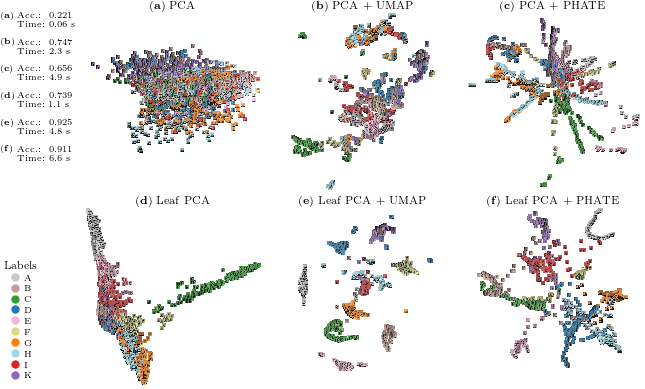

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox



# -----------------------------------------------------------------------------
# Plot content mode
# -----------------------------------------------------------------------------
PLOT_CONTENT = "test_images"          # "dots" or "test_images"
TEST_IMAGE_SUBSAMPLE = 10000     # total number of test images to draw per subplot
TEST_IMAGE_ZOOM = 0.015         # size of image thumbnails  (0.018 for Sign, 0.015 for Fashion)
TEST_IMAGE_SEED = 0
IMAGE_TINT_STRENGTH = 0.70
IMAGE_UPSAMPLE = 6
IMAGE_INTERPOLATION = "bilinear"   # or "bicubic"

DATA_ROOT = Path("/Users/aumona/Projects/RF-GAP-Python/data")

IMAGE_SHAPES = {
    "sign_mnist": (28, 28),
    "fashion_mnist": (28, 28),
    "tissuemnist_28": (28, 28),
    "pathmnist_28": (28, 28),
}


# =============================================================================
# Global parameters
# =============================================================================

LEAF_RESULTS_DIR = Path("/Users/aumona/Projects/RF-GAP-Python/experiments/results/20260413_220048_leaf_embedding_experiments_sign")
# LEAF_RESULTS_DIR = Path("/Users/aumona/Projects/RF-GAP-Python/experiments/results/20260413_220850_leaf_embedding_experiments_fashion")
# LEAF_RESULTS_DIR = Path("/Users/aumona/Projects/RF-GAP-Python/experiments/results/20260413_221847_leaf_embedding_experiments_covtype")



# Sign MNIST SEED 44, KNN=50 for PHATE is good.
# For Fashion, seed=9, knn=50
# PLOT_DATASET = "fashion_mnist"  # "celegans", "pbmc", "sign_mnist", "tissuemnist_28", "fashion_mnist", 'covertype'
# PLOT_DATASET = "covertype"  # "celegans", "pbmc", "sign_mnist", "tissuemnist_28", "fashion_mnist", 'covertype'
PLOT_DATASET = "sign_mnist"  # "celegans", "pbmc", "sign_mnist", "tissuemnist_28", "fashion_mnist", 'covertype'

PLOT_SEED = 9  # 578, 9, 912, 345, 44

TRAIN_MARKER = "o"
TEST_MARKER = "^"
POINT_SIZE = 0.2
POINT_ALPHA_TRAIN = 1
POINT_ALPHA_TEST = 1

# Match paper text width
TEXT_WIDTH_PT = 492.0
PT_TO_IN = 1.0 / 72.27
FIG_WIDTH = TEXT_WIDTH_PT * PT_TO_IN

# More room on the left for the label legend column
LEFT = 0.17
RIGHT = 0.995
BOTTOM = 0.08
TOP = 0.84
WSPACE = 0.05
HSPACE = 0.08  # room betwen rows



SUBPLOT_MARKERS = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

TEXT_FONTSIZE = 6.6
TITLE_FONTSIZE = 7.8
LEGEND_FONTSIZE = 6.3

# Labels legend position (x-coordinate in figure fraction)
X_LABEL_LEGEND = 0.05

SHOW_SPLIT_MARKER_LEGEND = True
SPLIT_LEGEND_LOC = "lower left"

OUT_STEM = f"{PLOT_DATASET}_seed{PLOT_SEED}_embedding_grid_raw_vs_leaf"

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 7.5,
    "axes.labelsize": 8,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": LEGEND_FONTSIZE,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.01,
    "pdf.compression": 9,
})


# =============================================================================
# Helpers
# =============================================================================

def clean_display_title(title: str) -> str:
    title = title.replace("Raw ", "")
    title = re.sub(r"PCA\d+\s*\+\s*UMAP", "PCA + UMAP", title)
    title = re.sub(r"PCA\d+\s*\+\s*PHATE", "PCA + PHATE", title)
    return title

def format_runtime_seconds(x: float) -> str:
    if pd.isna(x):
        return "nan s"
    if x < 1:
        return f"{x:.2f} s"
    if x < 60:
        return f"{x:.1f} s"
    m = int(x // 60)
    s = x - 60 * m
    return f"{m}m {s:.0f}s"


def load_method_row(results_df: pd.DataFrame, dataset: str, seed: int, method_name: str) -> pd.Series:
    match = results_df[
        (results_df["dataset"] == dataset)
        & (results_df["seed"] == seed)
        & (results_df["method_name"] == method_name)
    ].copy()

    if len(match) == 0:
        raise ValueError(
            f"No row found for dataset={dataset}, seed={seed}, method_name={method_name}."
        )
    if len(match) > 1:
        raise ValueError(
            f"Multiple rows found for dataset={dataset}, seed={seed}, method_name={method_name}."
        )
    return match.iloc[0]


def load_embedding_pair(emb_dir: Path, dataset: str, seed: int, train_file: str, test_file: str):
    seed_dir = emb_dir / dataset / f"seed_{seed}"
    train_path = seed_dir / train_file
    test_path = seed_dir / test_file

    if not train_path.exists():
        raise FileNotFoundError(f"Missing train embedding file: {train_path}")
    if not test_path.exists():
        raise FileNotFoundError(f"Missing test embedding file: {test_path}")

    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)

    required_cols = {"label", "x1", "x2"}
    if not required_cols.issubset(df_train.columns):
        raise ValueError(f"{train_path.name} must contain columns {required_cols}")
    if not required_cols.issubset(df_test.columns):
        raise ValueError(f"{test_path.name} must contain columns {required_cols}")

    if PLOT_CONTENT == "test_images":
        if "row_id" not in df_test.columns:
            raise ValueError(
                f"{test_path.name} must contain a 'row_id' column for image plotting."
            )

    return df_train, df_test


def build_label_color_map(all_labels):
    unique_labels = pd.Index(pd.unique(pd.Series(all_labels))).tolist()
    cmap = plt.cm.get_cmap("tab20", max(len(unique_labels), 1))
    return {lab: cmap(i) for i, lab in enumerate(unique_labels)}

def upsample_rgb_image(rgb: np.ndarray, factor: int) -> np.ndarray:
    if factor <= 1:
        return rgb
    return np.repeat(np.repeat(rgb, factor, axis=0), factor, axis=1)

def load_original_image_table(dataset_name: str) -> pd.DataFrame:
    path_full = DATA_ROOT / f"{dataset_name}.parquet"
    path_train = DATA_ROOT / f"{dataset_name}_train.parquet"
    path_test = DATA_ROOT / f"{dataset_name}_test.parquet"

    if path_full.exists():
        df = pd.read_parquet(path_full).reset_index(drop=True).copy()
        df["row_id"] = np.arange(len(df))

    elif path_test.exists():
        # In image plotting mode we only display test embeddings, so row_id must
        # match the test embedding row ids. Therefore load only the test parquet.
        df = pd.read_parquet(path_test).reset_index(drop=True).copy()
        df["row_id"] = np.arange(len(df))

    else:
        raise FileNotFoundError(
            "Could not find original dataset parquet. Expected one of:\n"
            f"  {path_full}\n"
            f"  {path_test}"
        )

    if dataset_name not in IMAGE_SHAPES:
        raise ValueError(
            f"Unknown image shape for dataset '{dataset_name}'. "
            f"Please add it to IMAGE_SHAPES."
        )

    label_col = df.columns[0]
    pixel_cols = [c for c in df.columns if c not in {label_col, "row_id"}]

    return df[["row_id", label_col] + pixel_cols].rename(columns={label_col: "label"})


def stratified_subsample(df: pd.DataFrame, n_total: int, seed: int = 0) -> pd.DataFrame:
    if len(df) <= n_total:
        return df.copy()

    rng = np.random.default_rng(seed)
    groups = []
    class_counts = df["label"].value_counts().sort_index()
    weights = class_counts / class_counts.sum()

    for lab, w in weights.items():
        g = df[df["label"] == lab]
        n_lab = max(1, int(round(n_total * w)))
        n_lab = min(n_lab, len(g))
        idx = rng.choice(g.index.to_numpy(), size=n_lab, replace=False)
        groups.append(df.loc[idx])

    out = pd.concat(groups, axis=0).drop_duplicates(subset=["row_id"])
    if len(out) > n_total:
        out = out.sample(n=n_total, random_state=seed)

    return out.reset_index(drop=True)


def tint_image(img_2d: np.ndarray, color_rgba, tint_strength: float = 0.70) -> np.ndarray:
    img = img_2d.astype(float)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()

    rgb = np.repeat(img[..., None], 3, axis=2)
    color = np.asarray(color_rgba[:3], dtype=float)[None, None, :]

    tinted = (1.0 - tint_strength) * rgb + tint_strength * (img[..., None] * color)
    tinted = np.clip(tinted, 0.0, 1.0)
    return tinted


def plot_test_images_on_ax(
    ax,
    df_test_emb: pd.DataFrame,
    image_table: pd.DataFrame,
    label_to_color: dict,
    dataset_name: str,
    n_images: int,
    zoom: float,
    seed: int,
):
    h, w = IMAGE_SHAPES[dataset_name]
    pixel_cols = [c for c in image_table.columns if c not in {"row_id", "label"}]

    df_plot = stratified_subsample(df_test_emb, n_total=n_images, seed=seed)
    df_plot = df_plot.merge(
        image_table[["row_id", "label"] + pixel_cols],
        on="row_id",
        how="left",
        suffixes=("", "_img"),
    )

    missing = df_plot[pixel_cols[0]].isna().sum()
    if missing > 0:
        print(f"Warning: {missing} sampled test images could not be matched by row_id.")

    for _, row in df_plot.iterrows():
        if pd.isna(row[pixel_cols[0]]):
            continue

        img = row[pixel_cols].to_numpy(dtype=float).reshape(h, w)
        color = label_to_color[row["label"]]
        rgb = tint_image(img, color, tint_strength=IMAGE_TINT_STRENGTH)
        rgb = upsample_rgb_image(rgb, IMAGE_UPSAMPLE)
        
        ab = AnnotationBbox(
            OffsetImage(rgb, zoom=zoom, interpolation=IMAGE_INTERPOLATION),
            (row["x1"], row["x2"]),
            frameon=False,
            pad=0.0,
            box_alignment=(0.5, 0.5),
            zorder=3,
        )
        ax.add_artist(ab)


def detect_method_specs(results_df: pd.DataFrame, dataset: str, seed: int):
    subset = results_df[
        (results_df["dataset"] == dataset)
        & (results_df["seed"] == seed)
    ].copy()

    available_methods = set(subset["method_name"].unique())

    required_fixed = {"raw_pca", "leaf_pca"}
    missing_fixed = sorted(required_fixed - available_methods)
    if missing_fixed:
        raise ValueError(
            f"Missing required methods for dataset={dataset}, seed={seed}: {missing_fixed}"
        )

    raw_pca_umap_methods = sorted(
        [m for m in available_methods if re.fullmatch(r"raw_pca\d+_umap", str(m))],
        key=lambda s: int(re.search(r"\d+", s).group())
    )
    leaf_pca_umap_methods = sorted(
        [m for m in available_methods if re.fullmatch(r"leaf_pca\d+_umap", str(m))],
        key=lambda s: int(re.search(r"\d+", s).group())
    )
    raw_pca_phate_methods = sorted(
        [m for m in available_methods if re.fullmatch(r"raw_pca\d+_phate", str(m))],
        key=lambda s: int(re.search(r"\d+", s).group())
    )
    leaf_pca_phate_methods = sorted(
        [m for m in available_methods if re.fullmatch(r"leaf_pca\d+_phate", str(m))],
        key=lambda s: int(re.search(r"\d+", s).group())
    )

    if len(raw_pca_umap_methods) == 0:
        raise ValueError(f"No raw_pca*_umap method found for dataset={dataset}, seed={seed}.")
    if len(leaf_pca_umap_methods) == 0:
        raise ValueError(f"No leaf_pca*_umap method found for dataset={dataset}, seed={seed}.")
    if len(raw_pca_phate_methods) == 0:
        raise ValueError(f"No raw_pca*_phate method found for dataset={dataset}, seed={seed}.")
    if len(leaf_pca_phate_methods) == 0:
        raise ValueError(f"No leaf_pca*_phate method found for dataset={dataset}, seed={seed}.")

    raw_pca_umap_method = raw_pca_umap_methods[-1]
    leaf_pca_umap_method = leaf_pca_umap_methods[-1]
    raw_pca_phate_method = raw_pca_phate_methods[-1]
    leaf_pca_phate_method = leaf_pca_phate_methods[-1]

    raw_pca_umap_k = int(re.search(r"raw_pca(\d+)_umap", raw_pca_umap_method).group(1))
    leaf_pca_umap_k = int(re.search(r"leaf_pca(\d+)_umap", leaf_pca_umap_method).group(1))
    raw_pca_phate_k = int(re.search(r"raw_pca(\d+)_phate", raw_pca_phate_method).group(1))
    leaf_pca_phate_k = int(re.search(r"leaf_pca(\d+)_phate", leaf_pca_phate_method).group(1))

    return [
        {
            "method_name": "raw_pca",
            "title": "Raw PCA",
            "train_file": "raw_pca_train.csv",
            "test_file": "raw_pca_test.csv",
            "row": 0,
            "col": 0,
        },
        {
            "method_name": raw_pca_umap_method,
            "title": f"Raw PCA{raw_pca_umap_k} + UMAP",
            "train_file": f"raw_pca{raw_pca_umap_k}_umap_train.csv",
            "test_file": f"raw_pca{raw_pca_umap_k}_umap_test.csv",
            "row": 0,
            "col": 1,
        },
        {
            "method_name": raw_pca_phate_method,
            "title": f"Raw PCA{raw_pca_phate_k} + PHATE",
            "train_file": f"raw_pca{raw_pca_phate_k}_phate_train.csv",
            "test_file": f"raw_pca{raw_pca_phate_k}_phate_test.csv",
            "row": 0,
            "col": 2,
        },
        {
            "method_name": "leaf_pca",
            "title": "Leaf PCA",
            "train_file": "leaf_pca_train.csv",
            "test_file": "leaf_pca_test.csv",
            "row": 1,
            "col": 0,
        },
        {
            "method_name": leaf_pca_umap_method,
            "title": f"Leaf PCA{leaf_pca_umap_k} + UMAP",
            "train_file": f"leaf_pca{leaf_pca_umap_k}_umap_train.csv",
            "test_file": f"leaf_pca{leaf_pca_umap_k}_umap_test.csv",
            "row": 1,
            "col": 1,
        },
        {
            "method_name": leaf_pca_phate_method,
            "title": f"Leaf PCA{leaf_pca_phate_k} + PHATE",
            "train_file": f"leaf_pca{leaf_pca_phate_k}_phate_train.csv",
            "test_file": f"leaf_pca{leaf_pca_phate_k}_phate_test.csv",
            "row": 1,
            "col": 2,
        },
    ]


def set_square_limits(ax, x_all, y_all, pad_frac=0.04):
    x_min, x_max = x_all.min(), x_all.max()
    y_min, y_max = y_all.min(), y_all.max()

    x_mid = 0.5 * (x_min + x_max)
    y_mid = 0.5 * (y_min + y_max)

    half_range = max(x_max - x_min, y_max - y_min) * 0.5
    half_range *= (1 + pad_frac)

    ax.set_xlim(x_mid - half_range, x_mid + half_range)
    ax.set_ylim(y_mid - half_range, y_mid + half_range)
    ax.set_aspect("equal", adjustable="box")


# =============================================================================
# Load run outputs
# =============================================================================

results_csv = LEAF_RESULTS_DIR / "embedding_runtime_results.csv"
emb_dir = LEAF_RESULTS_DIR / "embeddings"

if not results_csv.exists():
    raise FileNotFoundError(f"Could not find results CSV: {results_csv}")
if not emb_dir.exists():
    raise FileNotFoundError(f"Could not find embeddings directory: {emb_dir}")

results_df = pd.read_csv(results_csv)
method_specs = detect_method_specs(results_df, PLOT_DATASET, PLOT_SEED)

all_labels = []
loaded = []

for spec in method_specs:
    row = load_method_row(results_df, PLOT_DATASET, PLOT_SEED, spec["method_name"])
    df_train, df_test = load_embedding_pair(
        emb_dir=emb_dir,
        dataset=PLOT_DATASET,
        seed=PLOT_SEED,
        train_file=spec["train_file"],
        test_file=spec["test_file"],
    )
    all_labels.extend(df_train["label"].tolist())
    all_labels.extend(df_test["label"].tolist())
    loaded.append((spec, row, df_train, df_test))

label_to_color = build_label_color_map(all_labels)

image_table = None
if PLOT_CONTENT == "test_images":
    image_table = load_original_image_table(PLOT_DATASET)


# =============================================================================
# Figure geometry
# =============================================================================

nrows = 2
ncols = 3
usable_width = FIG_WIDTH * (RIGHT - LEFT)
axes_width = usable_width / (ncols + (ncols - 1) * WSPACE)
fig_height = (nrows * axes_width + (nrows - 1) * HSPACE * axes_width) / (TOP - BOTTOM)

fig, axes = plt.subplots(nrows, ncols, figsize=(FIG_WIDTH, fig_height), squeeze=False)
fig.subplots_adjust(
    left=LEFT,
    right=RIGHT,
    bottom=BOTTOM,
    top=TOP,
    wspace=WSPACE,
    hspace=HSPACE,
)



# =============================================================================
# Plot
# =============================================================================

for spec, row, df_train, df_test in loaded:
    ax = axes[spec["row"], spec["col"]]

    if PLOT_CONTENT == "dots":
        train_colors = [label_to_color[lab] for lab in df_train["label"]]
        test_colors = [label_to_color[lab] for lab in df_test["label"]]

        ax.scatter(
            df_train["x1"],
            df_train["x2"],
            s=POINT_SIZE,
            c=train_colors,
            marker=TRAIN_MARKER,
            alpha=POINT_ALPHA_TRAIN,
            linewidths=0,
            rasterized=False,
        )

        ax.scatter(
            df_test["x1"],
            df_test["x2"],
            s=POINT_SIZE,
            c=test_colors,
            marker=TEST_MARKER,
            alpha=POINT_ALPHA_TEST,
            linewidths=0,
            rasterized=False,
        )

    elif PLOT_CONTENT == "test_images":
        plot_test_images_on_ax(
            ax=ax,
            df_test_emb=df_test,
            image_table=image_table,
            label_to_color=label_to_color,
            dataset_name=PLOT_DATASET,
            n_images=TEST_IMAGE_SUBSAMPLE,
            zoom=TEST_IMAGE_ZOOM,
            seed=TEST_IMAGE_SEED,
        )

    else:
        raise ValueError(f"Unknown PLOT_CONTENT: {PLOT_CONTENT}")

    xy_all = pd.concat(
        [df_train[["x1", "x2"]], df_test[["x1", "x2"]]],
        axis=0,
        ignore_index=True,
    )
    set_square_limits(
        ax,
        xy_all["x1"].to_numpy(),
        xy_all["x2"].to_numpy(),
        pad_frac=0.04,
    )

    subplot_idx = spec["row"] * ncols + spec["col"]
    subplot_marker = SUBPLOT_MARKERS[subplot_idx]
    display_title = clean_display_title(spec["title"])

    ax.set_title(
        r"$\mathbf{" + subplot_marker.replace(" ", r"\ ") + "}$" + " " + display_title,
        pad=1,
    )

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


# -----------------------------------------------------------------------------
# Left-side accuracy/time block with fixed columns
# -----------------------------------------------------------------------------
X_MODEL_MARK = X_LABEL_LEGEND
X_MODEL_KEY = X_LABEL_LEGEND + 0.023
X_MODEL_VAL = X_LABEL_LEGEND + 0.070

Y_MODEL_TOP = 0.84
MODEL_BLOCK_DY = 0.054
MODEL_LINE_DY = 0.018

for i, (spec, row, _, _) in enumerate(loaded):
    subplot_idx = spec["row"] * ncols + spec["col"]
    subplot_marker = SUBPLOT_MARKERS[subplot_idx]

    knn_acc = row["knn_test_acc_avg"]
    runtime = row["train_total_time_s"] + row["test_total_time_s"]

    y_top = Y_MODEL_TOP - i * MODEL_BLOCK_DY
    y_bottom = y_top - MODEL_LINE_DY

    fig.text(
        X_MODEL_MARK,
        y_top,
        r"$\mathbf{" + subplot_marker.replace(" ", r"\ ") + "}$",
        ha="left",
        va="top",
        fontsize=LEGEND_FONTSIZE,
        transform=fig.transFigure,
    )
    fig.text(
        X_MODEL_KEY,
        y_top,
        "Acc.:",
        ha="left",
        va="top",
        fontsize=LEGEND_FONTSIZE,
        transform=fig.transFigure,
    )
    fig.text(
        X_MODEL_VAL,
        y_top,
        f"{knn_acc:.3f}",
        ha="left",
        va="top",
        fontsize=LEGEND_FONTSIZE,
        transform=fig.transFigure,
    )

    fig.text(
        X_MODEL_KEY,
        y_bottom,
        "Time:",
        ha="left",
        va="top",
        fontsize=LEGEND_FONTSIZE,
        transform=fig.transFigure,
    )
    fig.text(
        X_MODEL_VAL,
        y_bottom,
        f"{format_runtime_seconds(runtime)}",
        ha="left",
        va="top",
        fontsize=LEGEND_FONTSIZE,
        transform=fig.transFigure,
    )


# -----------------------------------------------------------------------------
# Labels + Train/Test legend
# -----------------------------------------------------------------------------
label_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color=label_to_color[lab],
        linestyle="None",
        markersize=5,
        label=str(lab),
    )
    for lab in sorted(label_to_color.keys(), key=lambda x: str(x))
]

combined_handles = list(label_handles)
combined_labels = [h.get_label() for h in label_handles]

if SHOW_SPLIT_MARKER_LEGEND and PLOT_CONTENT == "dots":
    combined_handles.extend([
        Line2D([], [], linestyle="None", marker=None, color="none", label=""),
        Line2D(
            [0], [0],
            marker=TRAIN_MARKER,
            color="black",
            linestyle="None",
            markersize=5,
            label="Train",
        ),
        Line2D(
            [0], [0],
            marker=TEST_MARKER,
            color="black",
            linestyle="None",
            markersize=5,
            label="Test",
        ),
    ])
    combined_labels.extend(["", "Train", "Test"])

left_legend = fig.legend(
    handles=combined_handles,
    labels=combined_labels,
    loc="lower left",
    bbox_to_anchor=(X_LABEL_LEGEND, 0.09),
    bbox_transform=fig.transFigure,
    ncol=1,
    frameon=False,
    title="Labels",
    borderaxespad=0.0,
    handletextpad=0.4,
    labelspacing=0.35,
    columnspacing=0.6,
    handlelength=1.2,
)


# -----------------------------------------------------------------------------
# Output directory
# -----------------------------------------------------------------------------
OUT_DIR = Path("/Users/aumona/Projects/RF-GAP-Python/experiments/notebooks/compiled_embedding_figure")
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_base = OUT_DIR / OUT_STEM

fig.savefig(out_base.with_suffix(".pdf"), bbox_extra_artists=[left_legend])
fig.savefig(out_base.with_suffix(".png"), dpi=600, bbox_extra_artists=[left_legend])

plt.show()